In [18]:
import cv2 
import numpy as np
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio as psnr

from matplotlib import pyplot as plt

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

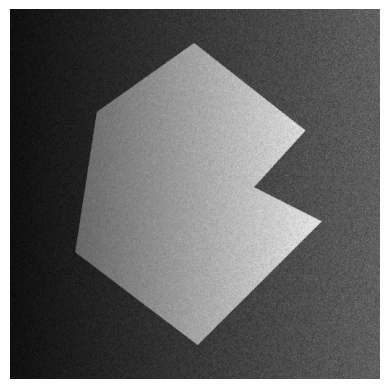

In [19]:
img = cv2.imread('septagon_noisy_shaded.tif', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (512, 512))
plt.imshow(img, cmap='gray')
plt.axis('off')

add some salt & pepper noise 

In [20]:
def salt_and_pepper_noise(img, amount, salt_vs_pepper):
    noisy = np.copy(img)
    total_pixels = noisy.size

    num_salt = int(amount * total_pixels * salt_vs_pepper)
    num_pepper = int(amount * total_pixels * (1.0 - salt_vs_pepper))


    # add salt (white pixels)
    coordinates = [np.random.randint(0, i-1, num_salt) for i in noisy.shape]
    noisy[coordinates[0], coordinates[1]] = 255

    # add pepper (black pixels)
    coordinates = [np.random.randint(0, i-1, num_pepper) for i in noisy.shape]
    noisy[coordinates[0], coordinates[1]] = 0

    return noisy

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

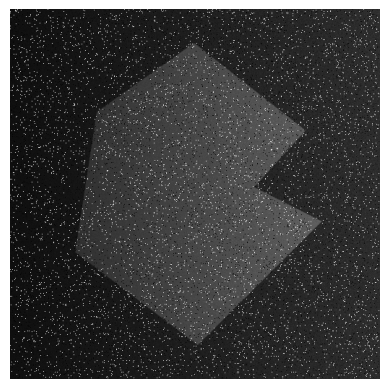

In [21]:
nimg = salt_and_pepper_noise(img, amount=0.05, salt_vs_pepper=0.5)
plt.imshow(nimg, cmap='gray')
plt.axis('off')

Filter

In [22]:
def average_filter(img, mask):
    pad = mask//2
    padded_img = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)
    kernel_value = 1.0/(mask**2)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            block = padded_img[i:i+mask, j:j+mask]
            output[i,j] = np.sum(block)*kernel_value

    return np.clip(output, 0, 255).astype(np.uint8)

In [23]:
def median_filer(img, mask):
    pad = mask//2
    padded_img = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            block = padded_img[i:i+mask, j:j+mask]
            output[i,j] = np.median(block)
    return np.clip(output, 0, 255).astype(np.uint8)

In [24]:
def geometric_filter(img, mask):
    img = img.astype(np.float32) + 1e-5
    pad = mask//2
    padded_image = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)
    p = 1.0/(mask**2)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            block = padded_image[i:i+mask, j:j+mask]
            output[i,j] = np.exp(np.mean(np.log(block)))
    return np.clip(output, 0, 255).astype(np.uint8)

In [25]:
def harmonic_filter(img, mask):
    img = img.astype(np.float32) + 1e-5
    pad = mask//2
    padded_image = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)
    p = mask*mask

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            block = padded_image[i:i+mask, j:j+mask]
            output[i,j] = p/(np.sum(1.0/block))
    return np.clip(output, 0, 255).astype(np.uint8)

In [26]:
def psnr(img, nimg):
    mse = np.mean((img-nimg)**2)
    if mse==0:
        return float('inf')
    max_pixel = 255.0
    psn = 20*np.log10((max_pixel/mse))
    return psn

(a) Apply average and median spatial filters with 5x5 mask and observe their performance for noise suppression in term of PSNR

avg:  32.969880592216555
med:  28.008819746629765


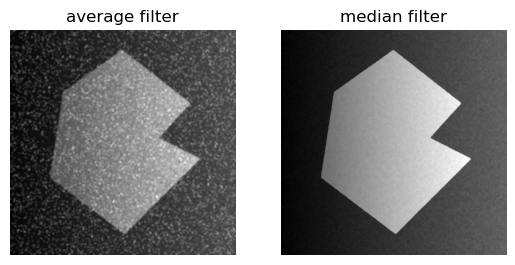

In [27]:
avg_img = average_filter(nimg, mask=5)
med_img = median_filer(nimg, mask=5)
avg_psnr = psnr(img, nimg)
med_psnr = psnr(img, med_img)
print("avg: ", avg_psnr)
print("med: ", med_psnr)

plt.subplot(1,2,1)
plt.title("average filter")
plt.imshow(avg_img, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title("median filter")
plt.imshow(med_img, cmap='gray')
plt.axis('off')
plt.show()

(b) Use different size of mask (3x3, 5x5, 7x7) with average filter for noise suppression and observe their performance in term of PSNR

In [28]:
for mask in [3,5,7]:
    avg_img = average_filter(nimg, mask)
    avg_psnr = psnr(img, avg_img)
    print(f"psnrt for kernel {mask}x{mask} : {avg_psnr}")

psnrt for kernel 3x3 : 16.789342117451536
psnrt for kernel 5x5 : 15.633740243315856
psnrt for kernel 7x7 : 16.322601626290385


(c) Apply harmonic and geometric mean filter on the noisy image and compare their
performance with PSNR

har:  12.392695004269992
geo:  32.969880592216555


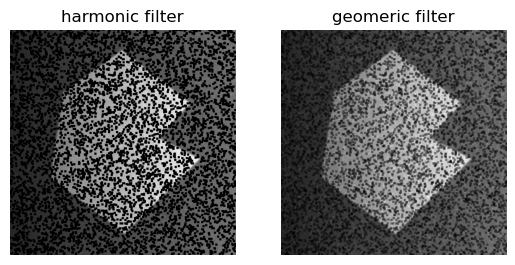

In [29]:
har_img = harmonic_filter(nimg, 5)
har_psnr = psnr(img, har_img)

geo_img = geometric_filter(nimg, 5)
geo_psnr = psnr(img, nimg)

print("har: ", har_psnr)
print("geo: ", geo_psnr)

plt.subplot(1,2,1)
plt.title("harmonic filter")
plt.imshow(har_img, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title("geomeric filter")
plt.imshow(geo_img, cmap='gray')
plt.axis('off')
plt.show()